# Imputation Comparison Results — Table and Visualizations

Source: `imputation_comparison_results.csv` (per-feature RMSE and MAE for Mean, Median, KNN).

Goals:
1. Show the raw data as a readable table with the best method highlighted per feature.
2. Visualization 1 — diverging bar of KNN improvement over Mean (scale-free, answers "who wins where?").
3. Visualization 2 — log-scale grouped bars of absolute RMSE (shows vastly different scales together).

In [10]:
import pandas as pd

df = pd.read_csv("imputation_comparison_results.csv")
print(f"Shape: {df.shape}")
df.head(20)

Shape: (17, 7)


,Feature,Mean_RMSE,Mean_MAE,Median_RMSE,Median_MAE,KNN_RMSE,KNN_MAE
0,bedrooms,0.883,0.720,0.952,0.649,0.937,0.683
1,bathrooms,0.743,0.599,0.753,0.592,0.652,0.483
2,sqft_living,882.496,687.636,897.413,676.405,824.623,599.674
3,sqft_lot,40454.205,13714.426,41115.384,10026.905,42329.593,11654.881
4,floors,0.532,0.485,0.532,0.485,0.461,0.331
5,waterfront,0.070,0.013,0.070,0.005,0.070,0.005
6,view,0.756,0.417,0.789,0.226,0.945,0.638
7,condition,0.651,0.561,0.771,0.433,0.697,0.523
8,grade,1.192,0.943,1.370,0.906,1.084,0.768
9,sqft_above,851.378,650.211,890.265,630.532,865.461,588.356


In [6]:
# Table: show raw values plus winner per feature (no jinja2 needed)
table = df.copy()
table["best_RMSE"] = table[["Mean_RMSE", "Median_RMSE", "KNN_RMSE"]].idxmin(axis=1).str.replace("_RMSE", "")
table["best_MAE"] = table[["Mean_MAE", "Median_MAE", "KNN_MAE"]].idxmin(axis=1).str.replace("_MAE", "")
table.round(3)

,Feature,Mean_RMSE,Mean_MAE,Median_RMSE,Median_MAE,KNN_RMSE,KNN_MAE,best_RMSE,best_MAE
0,bedrooms,0.883,0.720,0.952,0.649,0.937,0.683,Mean,Median
1,bathrooms,0.743,0.599,0.753,0.592,0.652,0.483,KNN,KNN
2,sqft_living,882.496,687.636,897.413,676.405,824.623,599.674,KNN,KNN
3,sqft_lot,40454.205,13714.426,41115.384,10026.905,42329.593,11654.881,Mean,Median
4,floors,0.532,0.485,0.532,0.485,0.461,0.331,KNN,KNN
5,waterfront,0.070,0.013,0.070,0.005,0.070,0.005,Mean,Median
6,view,0.756,0.417,0.789,0.226,0.945,0.638,Mean,Median
7,condition,0.651,0.561,0.771,0.433,0.697,0.523,Mean,Median
8,grade,1.192,0.943,1.370,0.906,1.084,0.768,KNN,KNN
9,sqft_above,851.378,650.211,890.265,630.532,865.461,588.356,Mean,KNN


## Visualization 1 — KNN improvement over Mean (diverging bar)

Raw errors cannot be averaged across features because `sqft_lot` (~40k) swamps `bathrooms` (~0.7). Converting to **percent improvement** puts every feature on the same scale:

$$\\text{improvement} = 100 \\times \\frac{\\text{Mean} - \\text{KNN}}{\\text{Mean}}$$

Positive (green, right) = KNN has lower error. Negative (red, left) = Mean has lower error.

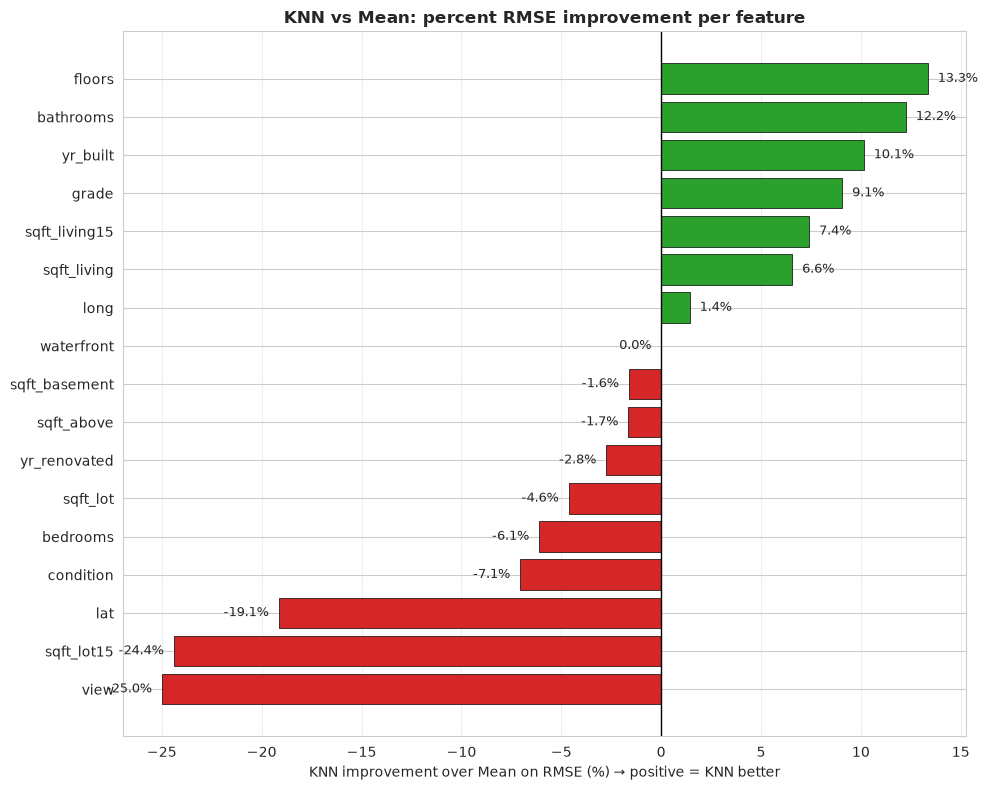

,Feature,Mean_RMSE,KNN_RMSE,RMSE_improv
6,view,0.76,0.94,-25.00
16,sqft_lot15,26305.84,32726.50,-24.41
13,lat,0.14,0.17,-19.15
7,condition,0.65,0.70,-7.07
0,bedrooms,0.88,0.94,-6.12
3,sqft_lot,40454.20,42329.59,-4.64
12,yr_renovated,408.40,419.67,-2.76
9,sqft_above,851.38,865.46,-1.65
10,sqft_basement,434.37,441.43,-1.63
5,waterfront,0.07,0.07,0.00


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plot_df = df.copy()
plot_df["RMSE_improv"] = 100 * (plot_df["Mean_RMSE"] - plot_df["KNN_RMSE"]) / plot_df["Mean_RMSE"]
plot_df["MAE_improv"] = 100 * (plot_df["Mean_MAE"] - plot_df["KNN_MAE"]) / plot_df["Mean_MAE"]
plot_df = plot_df.sort_values("RMSE_improv")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in plot_df["RMSE_improv"]]
ax.barh(plot_df["Feature"], plot_df["RMSE_improv"], color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("KNN improvement over Mean on RMSE (%) → positive = KNN better")
ax.set_title("KNN vs Mean: percent RMSE improvement per feature", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
for y, v in zip(plot_df["Feature"], plot_df["RMSE_improv"], strict=True):
    ax.text(v + (0.5 if v > 0 else -0.5), y, f"{v:.1f}%", va="center", ha="left" if v > 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

# Also print the sorted table for reference
plot_df[["Feature", "Mean_RMSE", "KNN_RMSE", "RMSE_improv"]].round(2)

## Visualization 2 — Absolute RMSE on a log scale (grouped bars)

This preserves absolute magnitudes but uses a **logarithmic y-axis** so features spanning 0.1 to 40,000 remain visible together. Each feature shows three side-by-side bars (Mean, Median, KNN). Use this when you need to see *how big* errors are, not just *who wins*.

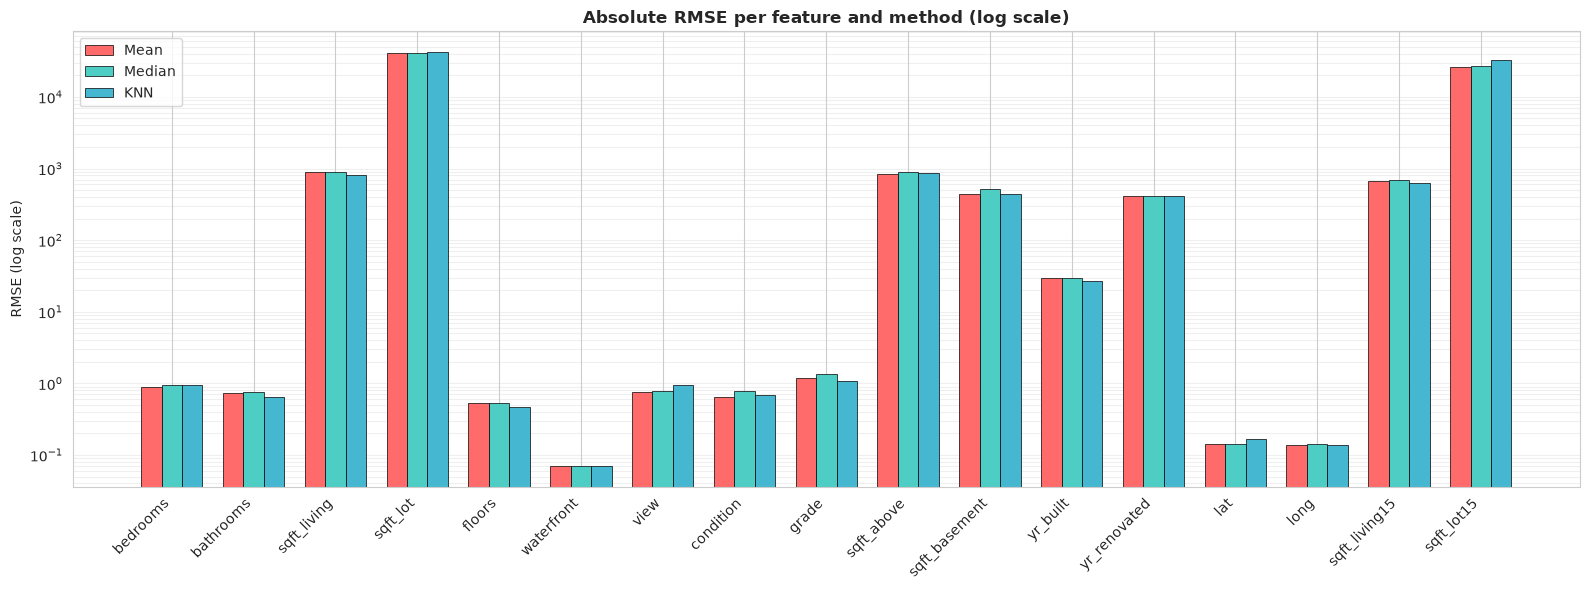

In [8]:
import matplotlib.pyplot as plt
import numpy as np

features = df["Feature"].tolist()
x = np.arange(len(features))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, df["Mean_RMSE"], width, label="Mean", color="#FF6B6B", edgecolor="black", linewidth=0.5)
ax.bar(x, df["Median_RMSE"], width, label="Median", color="#4ECDC4", edgecolor="black", linewidth=0.5)
ax.bar(x + width, df["KNN_RMSE"], width, label="KNN", color="#45B7D1", edgecolor="black", linewidth=0.5)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("RMSE (log scale)")
ax.set_title("Absolute RMSE per feature and method (log scale)", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3, which="both")
plt.tight_layout()
plt.show()